# Análisis Exploratorio de Tweets

En esta notebook se realiza un análisis exploratorio del dataset de tweets con el objetivo de comprender su estructura, distribución de clases y características generales antes de aplicar técnicas de procesamiento de lenguaje natural y modelos de clasificación.

In [2]:
#Imports

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

Analisis Dataset de Entrenamiento

In [3]:
#Carga del dataset

column_names = [
    "polarity",
    "id",
    "date",
    "query",
    "user",
    "text"
]

df = pd.read_csv(
    "../data/raw/training.1600000.processed.noemoticon.csv",
    encoding="latin-1",
    header=None,
    names=column_names
)

In [4]:
#Inspeccion Inicial

df.shape

(1600000, 6)

In [5]:
#Head

df.head()

,polarity,id,date,query,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [5]:
#Info

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 6 columns):
 #   Column    Non-Null Count    Dtype 
---  ------    --------------    ----- 
 0   polarity  1600000 non-null  int64 
 1   id        1600000 non-null  int64 
 2   date      1600000 non-null  object
 3   query     1600000 non-null  object
 4   user      1600000 non-null  object
 5   text      1600000 non-null  object
dtypes: int64(2), object(4)
memory usage: 73.2+ MB


In [6]:
#Null values

df.isnull().sum()

polarity    0
id          0
date        0
query       0
user        0
text        0
dtype: int64

In [7]:
#Distribucion de polaridad

df["polarity"].value_counts()

polarity
0    800000
4    800000
Name: count, dtype: int64

Visualización de la distribución de polaridad (Training)

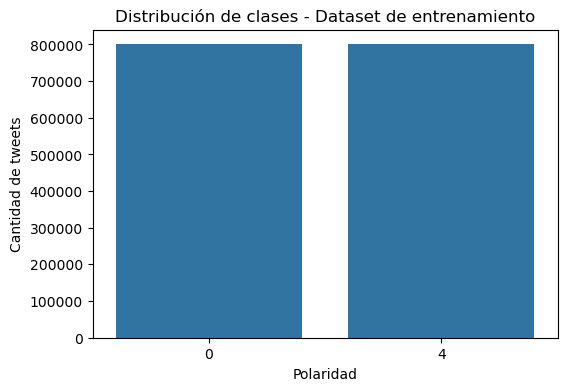

In [8]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="polarity")

plt.title("Distribución de clases - Dataset de entrenamiento")
plt.xlabel("Polaridad")
plt.ylabel("Cantidad de tweets")

plt.show()

Interpretación

El conjunto de entrenamiento contiene exactamente la misma cantidad de tweets positivos y negativos (800.000 por clase), por lo que no será necesario aplicar técnicas de balanceo durante el entrenamiento de los modelos.

Analisis Dataset de Test

In [9]:
#Carga del Dataset de Test

test_df = pd.read_csv(
    "../data/raw/testdata.manual.2009.06.14.csv",
    encoding="latin-1",
    header=None,
    names=column_names
)

In [10]:
#Inspeccion Inicial

test_df.shape

(498, 6)

In [11]:
#Head

test_df.head()

,polarity,id,date,query,user,text
0,4,3,Mon May 11 03:17:40 UTC 2009,kindle2,tpryan,@stellargirl I loooooooovvvvvveee my Kindle2. ...
1,4,4,Mon May 11 03:18:03 UTC 2009,kindle2,vcu451,Reading my kindle2... Love it... Lee childs i...
2,4,5,Mon May 11 03:18:54 UTC 2009,kindle2,chadfu,"Ok, first assesment of the #kindle2 ...it fuck..."
3,4,6,Mon May 11 03:19:04 UTC 2009,kindle2,SIX15,@kenburbary You'll love your Kindle2. I've had...
4,4,7,Mon May 11 03:21:41 UTC 2009,kindle2,yamarama,@mikefish Fair enough. But i have the Kindle2...


In [12]:
#Info

test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 498 entries, 0 to 497
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   polarity  498 non-null    int64 
 1   id        498 non-null    int64 
 2   date      498 non-null    object
 3   query     498 non-null    object
 4   user      498 non-null    object
 5   text      498 non-null    object
dtypes: int64(2), object(4)
memory usage: 23.5+ KB


In [13]:
#Null values

test_df.isnull().sum()

polarity    0
id          0
date        0
query       0
user        0
text        0
dtype: int64

In [14]:
#Distribucion de polaridad

test_df["polarity"].value_counts()

polarity
4    182
0    177
2    139
Name: count, dtype: int64

Visualización de la distribución de polaridad (Test)

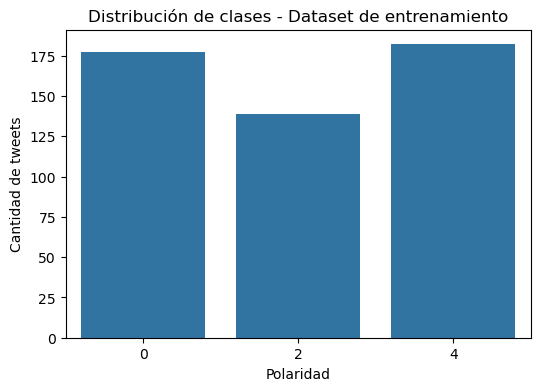

In [15]:
plt.figure(figsize=(6, 4))

sns.countplot(data=test_df, x="polarity")

plt.title("Distribución de clases - Dataset de entrenamiento")
plt.xlabel("Polaridad")
plt.ylabel("Cantidad de tweets")

plt.show()

In [ ]:
Conclusión:
El conjunto de entrenamiento está compuesto exclusivamente por tweets positivos y negativos, mientras que el conjunto 
de prueba incorpora además ejemplos con polaridad neutral. Dado que los modelos supervisados se entrenarán únicamente con 
las clases 0 y 4, la evaluación de dichos modelos se realizará sobre el subconjunto del dataset de prueba 
que contenga únicamente estas dos categorías. 
La clase neutral será considerada posteriormente al analizar el desempeño de modelos preentrenados.

Analisis de Variables

In [16]:
#Query
df["query"].value_counts()

query
NO_QUERY    1600000
Name: count, dtype: int64

Conlusion:Del análisis de las variables se concluye que únicamente text y polarity serán necesarias para el desarrollo del trabajo. Las columnas restantes corresponden a información identificatoria o contextual que no aporta valor para el problema de clasificación de sentimientos planteado.